In [25]:
import os
import sys
import warnings

# Path = '/remote/tychodata/ftairli/work/Projects/LSTM_Reconstruction/Models'
# if Path not in sys.path: sys.path.append(Path)
warnings.filterwarnings('ignore')

from matplotlib.lines import Line2D
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from copy import deepcopy

hostname = os.uname()
if 'tedtop' in hostname: sys.path.append('/home/fedor-tairli/work/CDEs/Dataset/')


from Dataset2 import ProcessingDatasetContainer

if 'tedtop' in hostname: plt.style.use('/home/fedor-tairli/work/MPLStylefiles/Vscode_DarkModern_Invisible.mplstyle')



In [26]:
Model_Name = 'Model_FlatTimeFit_Conv2d_Simple'

Dataset_Name = 'FlatTimeFit_Dataset'

In [27]:
hostname

posix.uname_result(sysname='Linux', nodename='tycho.physics.adelaide.edu.au', release='3.10.0-1160.88.1.el7.x86_64', version='#1 SMP Tue Mar 7 15:41:52 UTC 2023', machine='x86_64')

#### Loading Data and Models, Processing Predictions

In [28]:
if 'tycho' in hostname or 'tycho' in hostname.nodename:
    Models_Path  = '/remote/tychodata/ftairli/work/CDEs/FlatTimeFitConv2d/Models'
    Dataset_Path = '/remote/tychodata/ftairli/work/CDEs/FlatTimeFitConv2d/Data/'
if 'tedtop' in hostname:
    Models_Path  = '/home/fedor-tairli/work/CDEs/FlatTimeFitConv2d/Models'
    Dataset_Path = '/home/fedor-tairli/work/CDEs/FlatTimeFitConv2d/Data/'

# append models path to path
sys.path.append(Models_Path)


In [29]:
# Load Model and Tracker Here
Model = torch.load(f'{Models_Path}/{Model_Name}.pt')
Tracker = torch.load(f'{Models_Path}/{Model_Name}_Tracker.pt')
print(Model.Description)


    Flat Time Fit Tensor input
    Conv2d style architecture
    


In [30]:
# Import Dataset Here

# datapath = '/remote/tychodata/ftairli/work/Projects/ProfileReconstruction/Data/'
# Dataset = ProcessingDatasetContainer(datapath)
Dataset = torch.load(f'{Dataset_Path}/{Dataset_Name}.pt')
print(Dataset.Name)
print(Dataset.Truth_Keys)
print(f'Dataset Length : {len(Dataset)}')
Dataset.AssignIndices()
# Dataset.State = 'Train'
# print(len(Dataset))

Unassigned_EPOSLHC_R_Run010_EPOSLHC_R_Run030_EPOSLHC_R_Run080_EPOSLHC_R_Run030
['Chi_0', 'Rp', 'T0']
Dataset Length : 611590


In [31]:
# Some Information
print(f'Final Epoch             : {len(Tracker.EpochLoss["Total"])  } ')
if len(Tracker.EpochLoss)>10 :
    print(f'Epoch 10 Loss           : {Tracker.EpochLoss    ["Total"][9]} ')
    print(f'Epoch 10 Validation Loss: {Tracker.EpochValLoss ["Total"][9]} ')
print(f'Final Loss              : {Tracker.EpochLoss    ["Total"][-1]}')
print(f'Final Validation Loss   : {Tracker.EpochValLoss ["Total"][-1]}')


Final Epoch             : 3 
Final Loss              : 0.19256009985490943
Final Validation Loss   : 0.1873055100440979


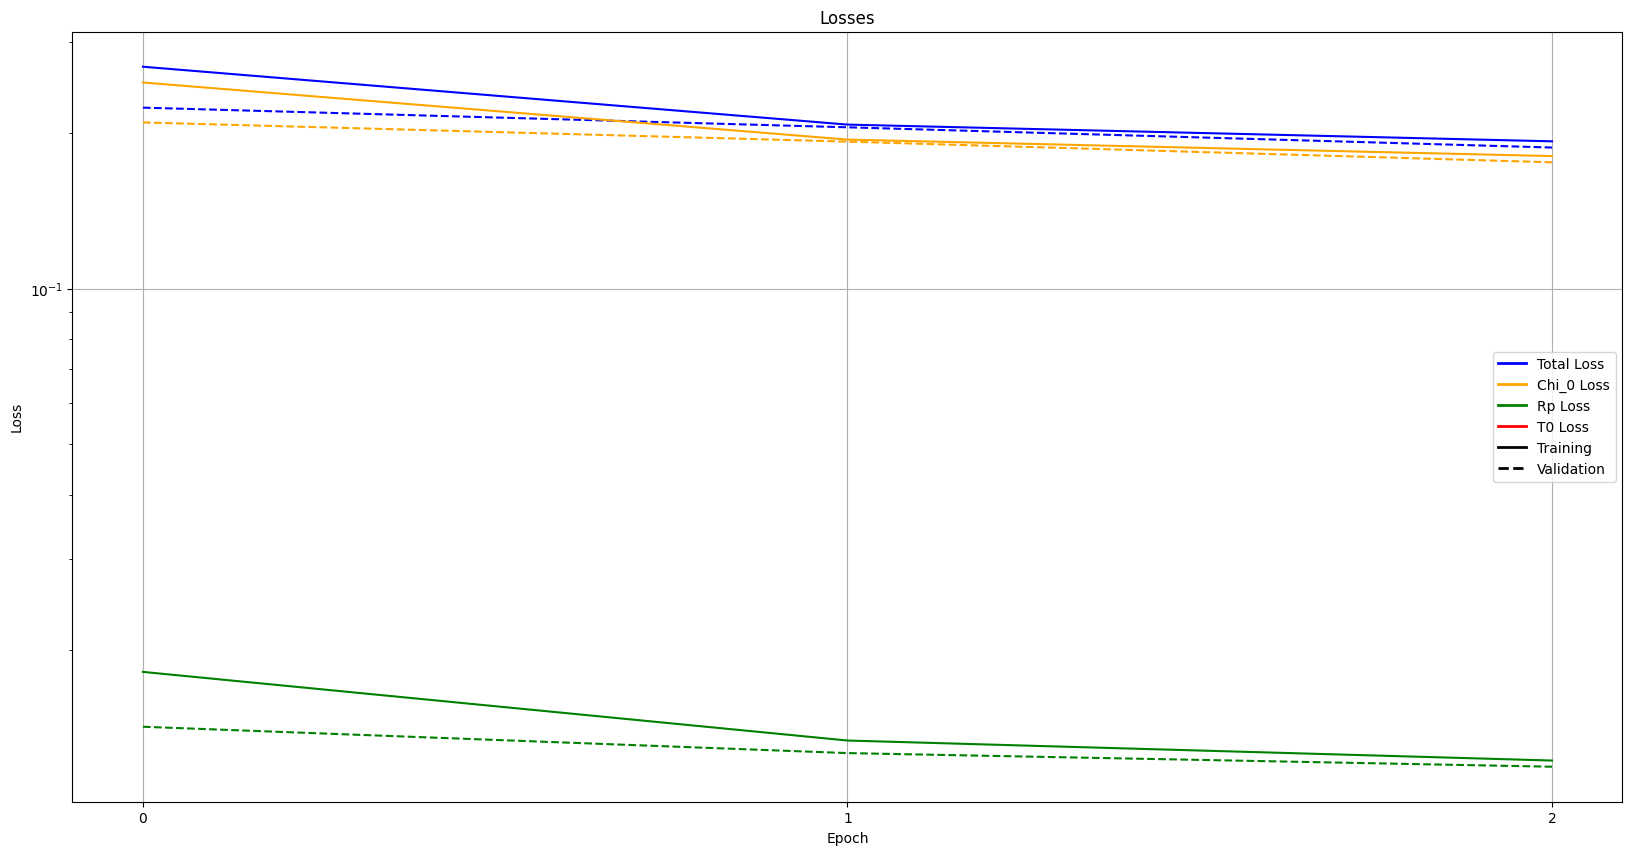

In [32]:
# Loss Plot
EpochLosses    = Tracker.EpochLoss
EpochValLosses = Tracker.EpochValLoss
Keys = list(EpochLosses.keys())
Nepochs = len(EpochLosses[Keys[0]])

ax = plt.figure(figsize=(20, 10)).gca()

# Define colors
colors = ['blue', 'orange', 'green', 'red','cyan','purple','magenta','yellow']


custom_lines = []
custom_keys  = []
for i in range(len(Keys)):
    plt.plot(EpochLosses[Keys[i]]   , color=colors[i], label=Keys[i] + ' - Training')
    plt.plot(EpochValLosses[Keys[i]], color=colors[i], label=Keys[i] + ' - Validation', linestyle='dashed')
    custom_lines.append(Line2D([0], [0], color=colors[i], lw=2))
    custom_keys.append(Keys[i]+' Loss')

custom_lines+= [Line2D([0], [0], color='black', lw=2),
                Line2D([0], [0], color='black', lw=2, linestyle='dashed')]
custom_keys += ['Training', 'Validation']


ax.legend(custom_lines, custom_keys)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True)) # integer ticks
ax.set_title('Losses')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_yscale('log')
ax.grid()

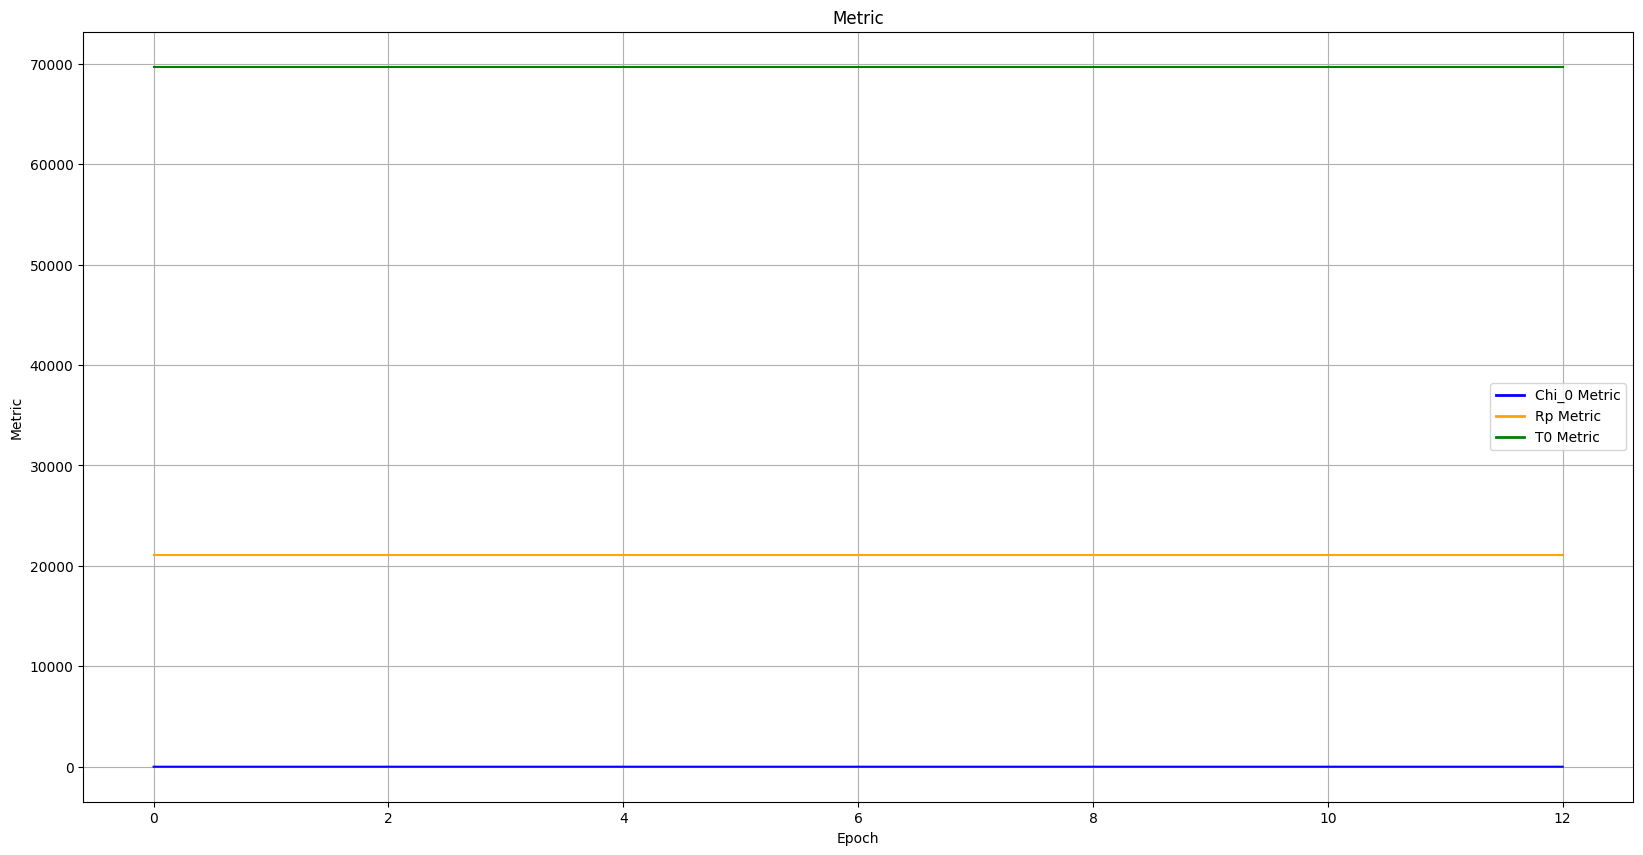

In [13]:
# Metric Plot

# Loss Plot
EpochMetrics    = Tracker.EpochMetric
Keys  = Dataset.Truth_Keys
Units = Dataset.Truth_Units
Nepochs = len(EpochLosses[Keys[0]])

ax = plt.figure(figsize=(20, 10)).gca()

# Define colors
colors = ['blue', 'orange', 'green', 'red','cyan','purple','magenta','yellow']


custom_lines = []
custom_keys  = []
for i in range(len(Keys)):
    plt.plot(np.array(EpochMetrics[Keys[i]])     , color=colors[i], label=Keys[i] + ' - Metric')
    custom_lines.append(Line2D([0], [0], color=colors[i], lw=2))
    custom_keys.append(Keys[i]+' Metric')



ax.legend(custom_lines, custom_keys)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True)) # integer ticks
ax.set_title('Metric')
ax.set_xlabel('Epoch')
ax.set_ylabel('Metric')
# ax.set_yscale('log')
ax.grid()

In [14]:
# Define some metrics
def MeanSquaredError(Truths,Predictions):
    return ((Truths-Predictions)**2).mean()
def MeanAbsoluteError(Truths,Predictions):
    return (np.abs(Truths-Predictions)).mean() if type(Truths) != torch.Tensor else (torch.abs(Truths-Predictions)).mean()
def Percentile68(Truths,Predictions):
    return np.percentile(np.abs(Truths-Predictions),68) if type(Truths) != torch.Tensor else torch.quantile(torch.abs(Truths-Predictions),0.68)

In [22]:
# Compute the Test Set
print(f'Computing Test Set for Model {Model.Name}') 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = torch.device('cpu')
Model.to(device)
torch.cuda.empty_cache()

Dataset.State      = 'Test'
Dataset.BatchSize  = len(Dataset)//256
# Dataset.BatchSize = 1
# Dataset.BatchSize  = 64
Dataset.RandomIter = False
Truth_Has_Been_Unnormalised = False

Truth   = []
Rec     = []
Pred    = []
PredChis= []
PredGeom= []
Mains   = []
Auxs    = []

latent_spaces = []
Acc_Loss_tracks = []

Model.eval()
EvI = 0
with torch.no_grad():
    for i,(EventIndex,BatchMains, BatchAux,BatchTruth,BatchRec) in enumerate(Dataset):
        if i%10==0: print(f'Batch {i} / {int(len(Dataset)/Dataset.BatchSize)}', end='\r')
        Truth .append(BatchTruth)
        Rec   .append(BatchRec)
        Mains .append(deepcopy(BatchMains))

        Auxs  .append(BatchAux)

        
        Model_Out = Model(BatchMains, BatchAux)

        PredGeom .append(Model_Out['geometry'    ].cpu())
        
        EvI+=1
        # if EvI == 10: break

print()
Truth   = torch.cat(Truth   , dim=0) if len(Truth) > 0 else torch.tensor([])
Rec     = torch.cat(Rec     , dim=0) if len(Rec) > 0 else torch.tensor([])
Pred    = torch.cat(Pred    , dim=0) if len(Pred) > 0 else torch.tensor([])
PredChis= torch.cat(PredChis, dim=0) if len(PredChis) > 0 else torch.tensor([])
PredGeom= torch.cat(PredGeom, dim=0) if len(PredGeom) > 0 else torch.tensor([])
Auxs    = torch.cat(Auxs    , dim=0) if len(Auxs) > 0 else torch.tensor([])

latent_spaces = torch.cat(latent_spaces, dim=0) if len(latent_spaces) > 0 else torch.tensor([])
Acc_Loss_tracks = torch.tensor(Acc_Loss_tracks) if len(Acc_Loss_tracks) > 0 else torch.tensor([])


Truth   = Truth.numpy()
Rec     = Rec  .numpy()
Pred    = Pred .numpy()
PredChis= PredChis.numpy()
PredGeom= PredGeom.numpy()
Auxs    = Auxs .numpy()

latent_spaces = latent_spaces.numpy()
Acc_Loss_tracks = Acc_Loss_tracks.numpy()


print(Truth.shape)
print(Pred.shape)
print(PredChis.shape)
print(PredGeom.shape)
print()
print(latent_spaces.shape)
print(Acc_Loss_tracks.shape)

chi_is = []
charge = []
times  = []

station_chii = []
station_time = []
station_signal = []

norm_min_time = []



# for Batch in Mains:
#     for Main in Batch:
#         chi_is.append(Main['chi_is'].numpy())
#         charge.append(Main['charge'].numpy())
#         times  .append(Main['time']  .numpy())

#         station_chii.append(Main['station_chii'].item())
#         station_time.append(Main['station_time'].item())
#         station_signal.append(Main['station_signal'].item())

#         norm_min_time.append(Main['norm_min_time'])

# station_time   = np.array(station_time)
# station_signal = np.array(station_signal)
# station_chii   = np.array(station_chii)

norm_min_time = np.array(norm_min_time)

print(f'Station Measurements lengths: {len(station_time)}, {len(station_signal)}, {len(station_chii)}')
print(f'Total Mains split into showers = {len(chi_is)}')
        

Computing Test Set for Model Model_FlatTimeFit_Conv2d_Simple
Batch 250 / 256
(61159, 3)
(0,)
(0,)
(61159, 3)

(0,)
(0,)
Station Measurements lengths: 0, 0, 0
Total Mains split into showers = 0


In [23]:
# Unnormalise Geometry Values
if not Truth_Has_Been_Unnormalised:
    Truth = Dataset.Unnormalise_Truth(torch.tensor(Truth)).numpy()
    PredGeom = Dataset.Unnormalise_Truth(torch.tensor(PredGeom)).numpy()
    Truth_Has_Been_Unnormalised = True
    print('Truth has been unnormalised')
else:
    print('Truth has already been unnormalised, skipping unnormalisation step')

Truth has been unnormalised


Total Points before cuts 61159
Chi_0 Total Points after cuts 61152
Rp Total Points after cuts 61105
T0 Total Points after cuts 16531


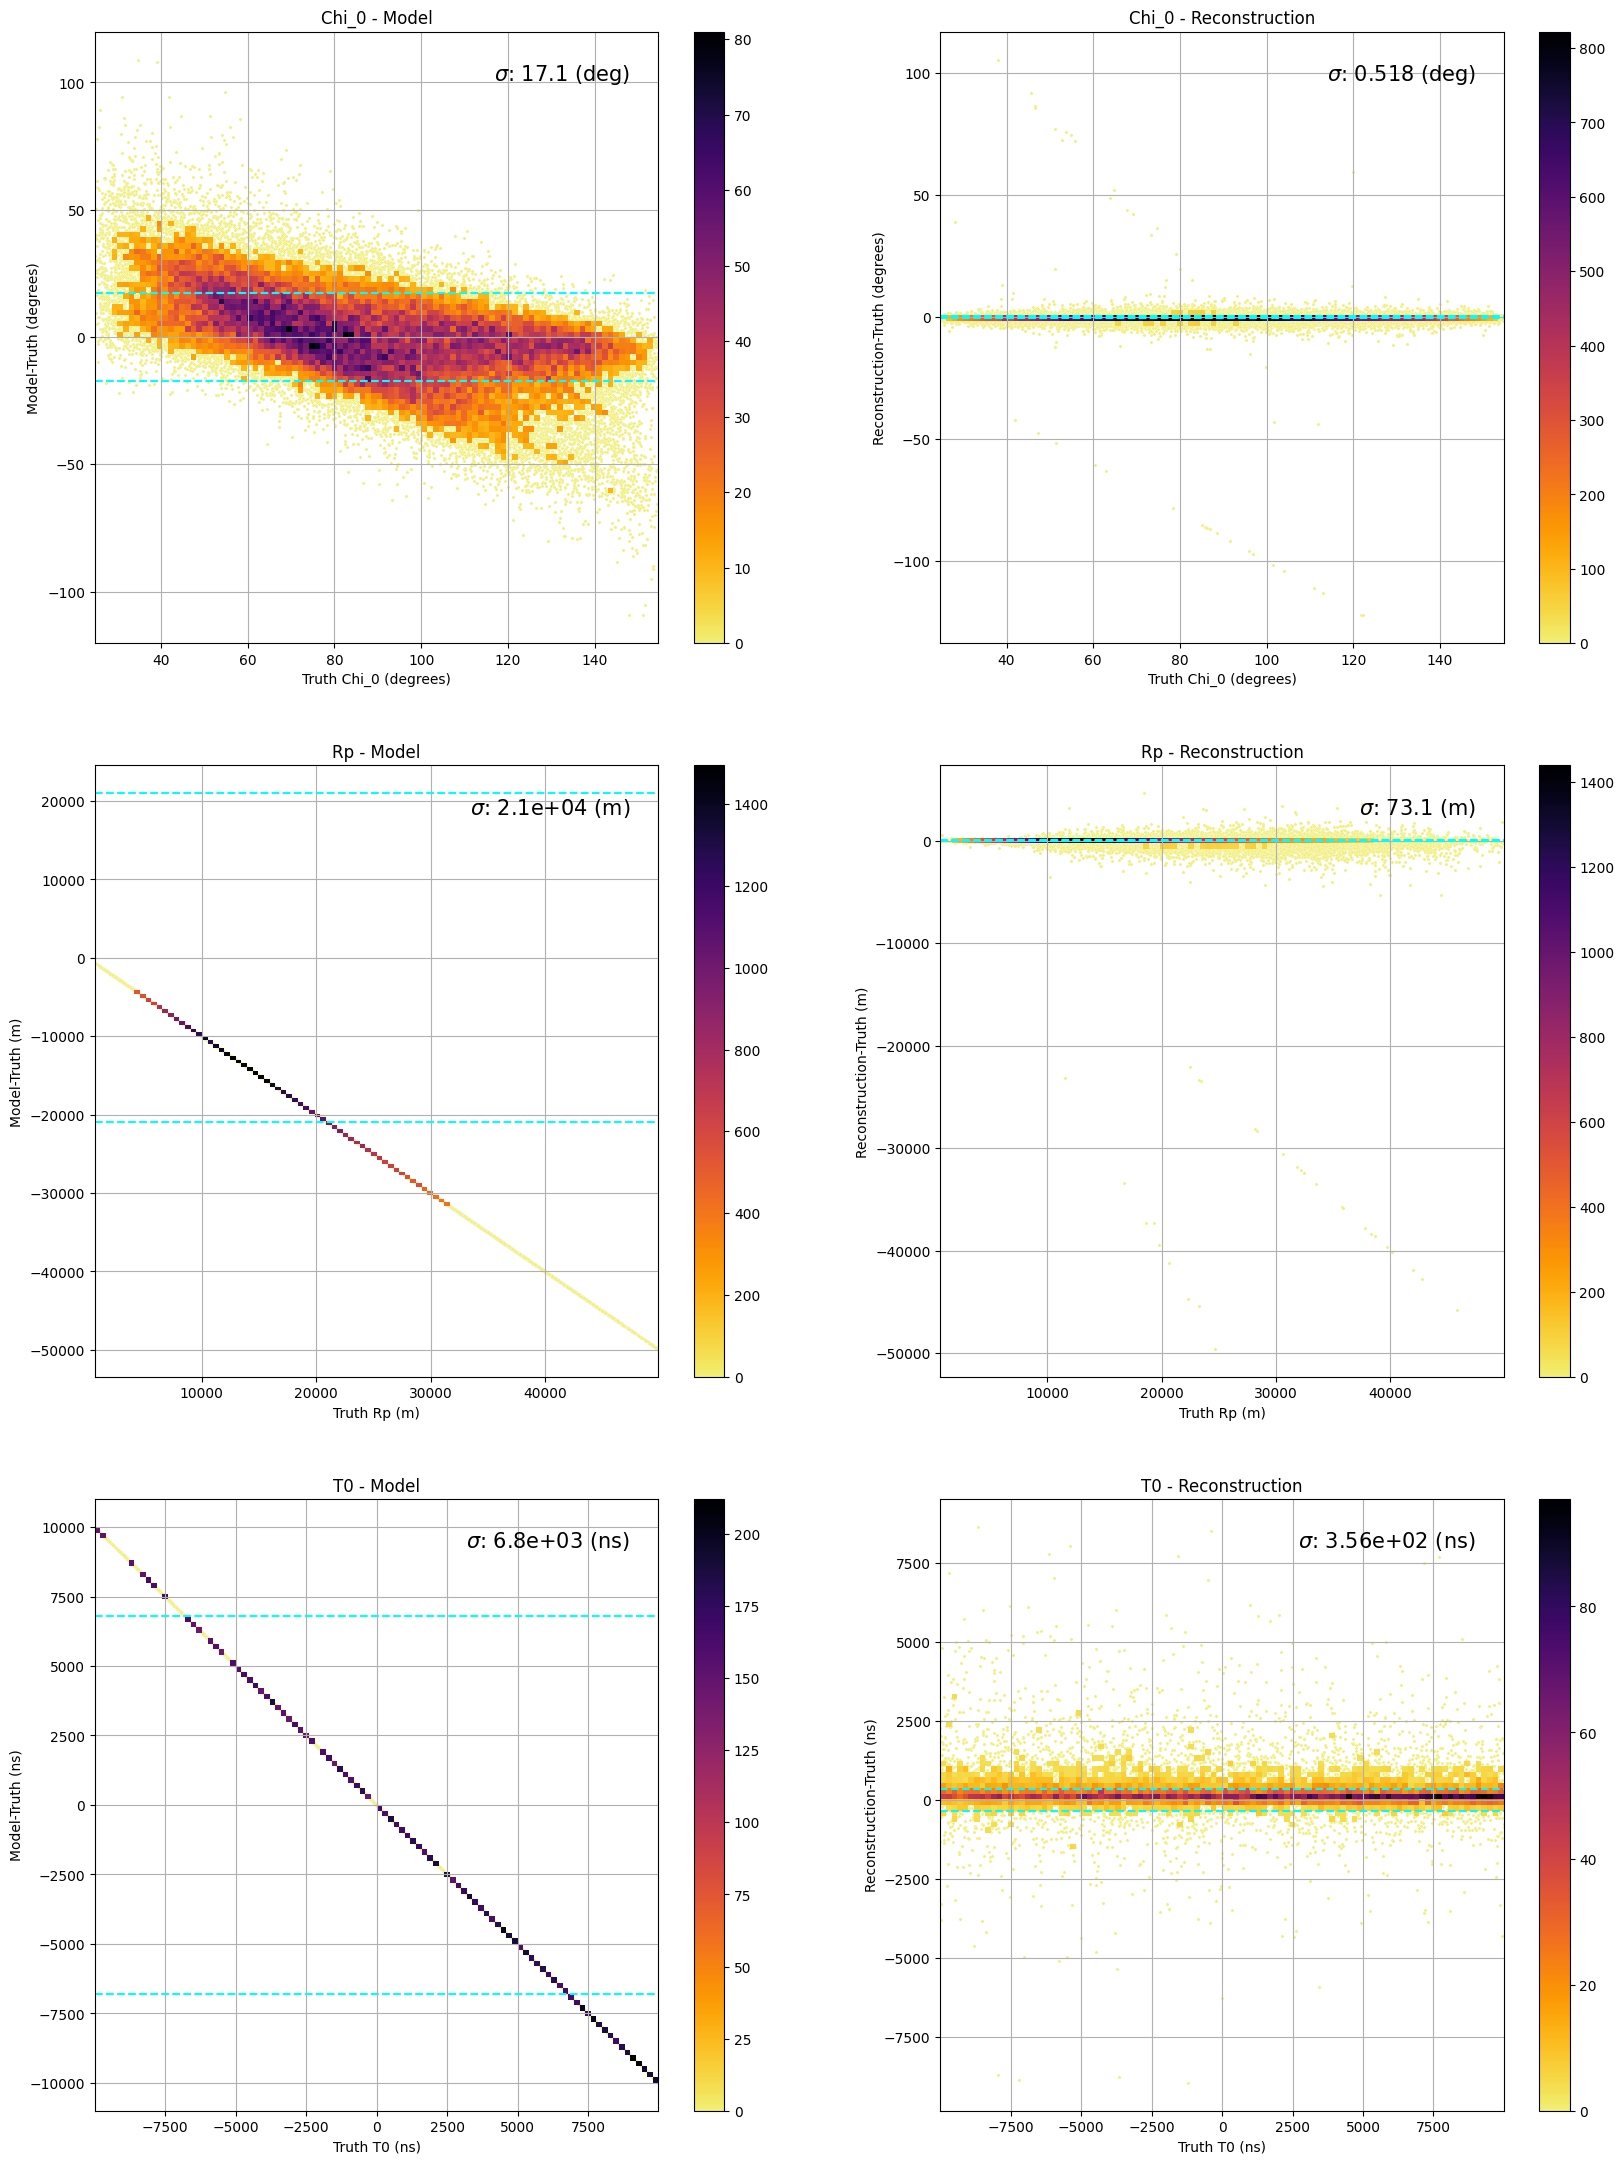

In [24]:
# Combined Deviation Plots Function Definition
from matplotlib.colors import LinearSegmentedColormap

# Create a truncated version of the inferno colormap (first 90%)
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = LinearSegmentedColormap.from_list(
        f'truncated_{cmap.name}', 
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

# Original inferno colormap
inferno = plt.get_cmap('inferno_r')

# Truncated colormap: first 90%
truncated_inferno = truncate_colormap(inferno, 0.05, 1)

def CombinedDeviationPlots(TruthKeys,TruthUnits,Truth,Pred,Rec):
    plt.style.use('default')
    fig, ax = plt.subplots(len(TruthKeys),2, figsize=(20,9*len(TruthKeys)))
    print(f'Total Points before cuts {len(Truth)}')
    for i in range(len(TruthKeys)):
        X  = Truth[:, i] if TruthUnits[i] != 'rad' else Truth[:, i]/np.pi*180
        Yp = Pred[:, i] - Truth[:, i] if TruthUnits[i] != 'rad' else (Pred[:, i] - Truth[:, i])/np.pi*180
        Yr = Rec [:, i] - Truth[:, i] if TruthUnits[i] != 'rad' else (Rec [:, i] - Truth[:, i])/np.pi*180
        
        # Scaling Cuts
        if   TruthKeys[i] == 'SDPTheta': cut = (np.abs(Yp)>0)  #& (np.abs(Yp)<20)    & (np.abs(Yr)<20)
        elif TruthKeys[i] == 'SDPPhi'  : cut = (np.abs(Yp)>0)  #& (np.abs(Yp)<20)    & (np.abs(Yr)<20) #   & (np.abs(X)<50)
        elif TruthKeys[i] == 'Chi0'    : cut = (np.abs(Yp)<20)    & (np.abs(Yr)<20)
        elif TruthKeys[i] == 'Rp'      : cut = (np.abs(Yp)<50000)  & (np.abs(Yr)<50000)
        elif TruthKeys[i] == 'CEDist'  : cut = (np.abs(Yp)<5000)  & (np.abs(Yr)<5000)
        elif TruthKeys[i] == 'T0'      : cut = (np.abs(Yp)<10000) & (np.abs(Yr)<10000)
        elif TruthKeys[i] == 'Xmax'    : cut = (np.abs(Yp)<200)   & (np.abs(Yr)<200)  & (X>100)
        elif TruthKeys[i] == 'LogE'    : cut = (X>0)             # & (np.abs(Yp)<3000)    & (np.abs(Yr)<3000)
        elif TruthKeys[i] == 'z'       : cut = (X>0.4) 
        else: cut = (np.abs(Yp)>0)

        
        X = X[cut]
        Yp = Yp[cut]
        Yr = Yr[cut]

        # Secondary Y_lim cuts for scaling
        # Yp_STD = np.percentile(np.abs(Yp),68)
        # cut = (np.abs(Yp)<5*Yp_STD) & (np.abs(Yr)<5*Yp_STD)
        # X  = X [cut]
        # Yp = Yp[cut]
        # Yr = Yr[cut]
        print(f'{TruthKeys[i]} Total Points after cuts {len(X)}')
        # sns.scatterplot(x=X, y=Yp, ax=ax[i,0], s=5,color='orange')
        # sns.scatterplot(x=X, y=Yr, ax=ax[i,1], s=5,color='orange')

        sns.scatterplot(x=X, y=Yp, ax=ax[i,0], s=5,color=truncated_inferno(0))
        sns.scatterplot(x=X, y=Yr, ax=ax[i,1], s=5,color=truncated_inferno(0))


        sns.histplot(x=X, y=Yp, ax=ax[i,0], bins=100, pthresh=0.1,cmap = truncated_inferno,cbar = True)
        sns.histplot(x=X, y=Yr, ax=ax[i,1], bins=100, pthresh=0.1,cmap = truncated_inferno,cbar = True)
        if TruthUnits[i] != 'rad': 
            ax[i,0].set_ylabel(f'Model-Truth ({TruthUnits[i]})')
            ax[i,0].set_xlabel(f'Truth {TruthKeys[i]} ({TruthUnits[i]})')

            ax[i,1].set_ylabel(f'Reconstruction-Truth ({TruthUnits[i]})')
            ax[i,1].set_xlabel(f'Truth {TruthKeys[i]} ({TruthUnits[i]})')

            
        else:                      
            ax[i,0].set_ylabel(f'Model-Truth (degrees)')
            ax[i,0].set_xlabel(f'Truth {TruthKeys[i]} (degrees)')

            ax[i,1].set_ylabel(f'Reconstruction-Truth (degrees)')
            ax[i,1].set_xlabel(f'Truth {TruthKeys[i]} (degrees)')
        
        ax[i,0].set_title(f'{TruthKeys[i]} - Model')
        ax[i,1].set_title(f'{TruthKeys[i]} - Reconstruction')

        ax[i,0].set_xlim(min(X),max(X))
        ax[i,1].set_xlim(min(X),max(X))

        ax[i,0].grid()
        ax[i,1].grid()

        # ax[0,1].set_facecolor('lightgrey')
        # ax[1,1].set_facecolor('lightgrey')


        # 68th Percentile
        Percentile68_p = np.percentile(np.abs(Yp),68)
        Percentile68_r = np.percentile(np.abs(Yr),68)

        # ax[i,0].set_ylim(-Percentile68_p*5,Percentile68_p*5)
        # ax[i,1].set_ylim(-Percentile68_p*5,Percentile68_p*5)



        # Add as a texbox to top right of plot
        if TruthUnits[i]!= 'rad':
            ax[i,0].text(0.95, 0.95, f'$\\sigma$: {Percentile68_p:.3} ({TruthUnits[i]})', verticalalignment='top', horizontalalignment='right', transform=ax[i,0].transAxes, fontsize=15)
            ax[i,1].text(0.95, 0.95, f'$\\sigma$: {Percentile68_r:.3} ({TruthUnits[i]})', verticalalignment='top', horizontalalignment='right', transform=ax[i,1].transAxes, fontsize=15)

        else:
            ax[i,0].text(0.95, 0.95, f'$\\sigma$: {Percentile68_p:.3} (deg)', verticalalignment='top', horizontalalignment='right', transform=ax[i,0].transAxes, fontsize=15)
            ax[i,1].text(0.95, 0.95, f'$\\sigma$: {Percentile68_r:.3} (deg)', verticalalignment='top', horizontalalignment='right', transform=ax[i,1].transAxes, fontsize=15)



        ax[i,0].axhline(Percentile68_p, color='cyan', linestyle='--')
        ax[i,0].axhline(-Percentile68_p, color='cyan', linestyle='--')

        ax[i,1].axhline(Percentile68_r, color='cyan', linestyle='--')
        ax[i,1].axhline(-Percentile68_r, color='cyan', linestyle='--')
        
    return fig


fig = CombinedDeviationPlots(Dataset.Truth_Keys,Dataset.Truth_Units,Truth,PredGeom,Rec)